# 插值

实际应用中经常遇到如下问题：通过试验观测，得到某个未知函数 $y = f(x)$ 的一系列数据点 $(x_i, y_i)$ ($i = 0, 1, \dots, n$)，一般要求 $x_0 < x_1 < \cdots < x_n$，但对于 $x$ 的其他值对应的函数值是未知的。因此，我们希望能通过这些数据点，得到函数的解析表达式。插值法是寻求函数近似表达式的有效方法之一。

为此，从性质优良、便于计算的函数类 $\{P(x)\}$ 中，选出一个使 $P(x_i) = y_i$ 成立的 $P(x)$ 作为 $f(x)$ 的近似，这就是最基本的插值问题。通常 $x_0, x_1, \dots, x_n$ 称为插值节点，$\{P(x)\}$ 称为插值函数类，$P(x_i) = y_i$ ($i = 0, 1, \dots, n$) 称为插值条件，求出的函数 $P(x)$ 称为插值函数，$f(x)$ 称为被插值函数。

插值函数类的取法有很多，可以是代数多项式，也可以是三角函数多项式或有理函数。由于代数多项式最简单，所以常用它来近似表达一些复杂的函数。

一维插值方法有很多，这里介绍一维 Lagrange 插值、分段线性插值、分段二次插值、牛顿插值和样条插值。二维插值仅介绍二维数据的双三次样条插值的思想。

### 7.1.1 插值方法

#### 1. Lagrange 插值

如果插值多项式为

$$
P(x) = \sum_{i=0}^{n} l_i(x) y_i,
\tag{7.1}
$$

其中，

$$
l_i(x) = \prod_{j=0, j \neq i}^{n} \frac{x - x_j}{x_i - x_j},
$$

则称其为 Lagrange 插值多项式。由 $l_i(x)$ 所表示的 $n$ 次多项式称为以 $x_0, x_1, \dots, x_n$ 为节点的 Lagrange 插值基函数。

 编写函数 Lag_intp(x, y, xO)，实现 Lagrange 插值．其中， x 和 y 是两
个具有相同长度的 NumPy 数组

In [5]:
def h(x, y, a):
    s = 0
    for i in range(len(y)):
        t = y[i]
        for j in range(len(y)):
            if i != j:
                t *= (a-x[j]) / (x[i]-x[j])  # l_i(x) = \prod_{j=0, j \neq i}^{n} \frac{x - x_j}{x_i - x_j}
        s += t  # P(x) = \sum_{i=0}^{n} l_i(x) y_i
    return s

#### 2. 分段线性插值

实际工作中，并非插值多项式次数越高误差越小，常采用分段多项式插值. 分段多项式插值就是求一个分段 (共$n$段) 多项式$P(x)$，使其满足插值条件或更高要求.

分段一次多项式插值，几何上就是用折线代替曲线$y = f(x)$，也称折线插值或分段线性插值. 分段线性插值多项式$P_1(x)$为
$$
P_1(x) = \frac{x - x_i}{x_{i+1} - x_i} y_{i+1} + \frac{x - x_{i+1}}{x_i - x_{i+1}} y_i,\quad x \in [x_i, x_{i+1}],\quad i = 0, 1, \cdots, n - 1. \tag{7.2}
$$


##### 3. 分段二次插值

这里插值函数$P_2(x)$是一个二次多项式，在几何上就是分段抛物线代替曲线$y = f(x)$，也称分段抛物线插值，此时要求有$2n + 1$个节点，其插值公式为
$$
\begin{aligned}
P_2(x) &= \frac{(x - x_{2i+1})(x - x_{2i+2})}{(x_{2i} - x_{2i+1})(x_{2i} - x_{2i+2})} y_{2i} + \frac{(x - x_{2i})(x - x_{2i+2})}{(x_{2i+1} - x_{2i})(x_{2i+1} - x_{2i+2})} y_{2i+1} \\
&\quad + \frac{(x - x_{2i})(x - x_{2i+1})}{(x_{2i+2} - x_{2i})(x_{2i+2} - x_{2i+1})} y_{2i+2},
\end{aligned} \tag{7.3}
$$
其中，$x \in [x_{2i}, x_{2i+2}]$, $i = 0, 1, 2, \cdots, n - 1$.

##### 4. 牛顿插值

在导出牛顿插值公式前，先介绍公式表示中所需要用到的差分和差商概念.

#### (1) 函数的差分

设有函数$f(x)$以及等距节点$x_i = x_0 + i h$ ($i = 0, 1, \cdots, n$)，步长$h$为常数，$f_i = f(x_i)$. 称相邻两个节点$x_i, x_{i+1}$处的函数值的增量$f_{i+1} - f_i$ ($i = 0, 1, \cdots, n - 1$) 为函数$f(x)$在点$x_i$处以$h$为步长的一阶前向差分，记为$\Delta f_i$，即
$$
\Delta f_i = f_{i+1} - f_i,\quad i = 0, 1, \cdots, n - 1.
$$

类似地，定义差分的差分为高阶差分. 如二阶前向差分为
$$
\Delta^2 f_i = \Delta f_{i+1} - \Delta f_i,\quad i = 0, 1, \cdots, n - 2.
$$

一般地，归纳定义$f(x)$的$m$阶前向差分$\Delta^m f(x)$如下：

(1) $\Delta^0 f(x) = f(x)$;

(2) $\Delta^m f(x) = \Delta^{m-1} f(x + h) - \Delta^{m-1} f(x)$.

In [6]:
# 差分
def finite_difference(f, k, h, x):
    if k <= 0:
        return f(x)
    else:
        return finite_difference(f, k-1, h, x+h) - finite_difference(f, k-1, h, x)

In [7]:
# 差商
"""
计算 n 阶差商 f[x0, x1, x2, ..., xn]
输入参数：xi为所有插值节点组成的数组
输入参数：fi为所有插值节点函数值组成数组
返回值：返回 xi 的 i 阶差商（i 为 xi 长度减 1）
"""
def difference_quotient(xi=[], fi=[]):  # 不传值默认为空
    if len(xi) > 2 and len(fi) >2:
        return ((difference_quotient(xi[:len(xi)-1]), fi[:len(fi)-1]) - difference_quotient(xi[1: len(xi)], fi[1: len(fi)])) / float(xi[0]-xi[-1])
    return (fi[0] - fi[1]) / float(xi[0] - xi[1])

In [8]:
# 等价于
def divided_difference(xi, yi):
    n = len(xi)
    if n == 1:
        return yi[0]
    elif n == 2:
        return (yi[0]-yi[1]) / (xi[0]-xi[1])
    else:
        # xi[:-1]切片操作不包括右端点
        fz = divided_difference(xi[:-1], yi[:-1]) - divided_difference(xi[1:], yi[1:])
        fm = xi[0] - xi[-1]
        return fz / fm

#### f = RegularGridInterpolator(points, values,
                            method='linear',   # 'nearest'|'linear'|'cubic'|'quintic'
                            bounds_error=True,
                            fill_value=np.nan)
                            
points：tuple，每个元素是一维升序坐标向量 (x1, x2, …, xN)  
values：N-D 数组，values[i1, i2, …, iN] 对应坐标点  
返回值可调用：z_new = f(xi)，xi 形状 (M, N)  

速查表：kind/method 与阶数  
'nearest'   → 0 阶最近邻  
'linear'    → 1 阶线性  
'slinear'   → 1 阶样条（线性 B-样条）  
'quadratic' → 2 阶样条  
'cubic'     → 3 阶样条  
'quintic'   → 5 阶样条（仅高维张量积可用）  

#### f = RectBivariateSpline(x, y, z,
                        kx=3, ky=3,      # x/y 方向样条阶数
                        s=0)             # 平滑系数，s=0 精确插值
                        
x, y：一维升序坐标向量  
z：二维矩阵 z[i, j] 对应 (x[i], y[j])  
返回值可调用：z_new = f.ev(x_new, y_new)；额外提供 f(x, y, dx=1, dy=0) 求偏导  

##### zi = griddata(points, values, xi,
              method='linear',    # 'nearest'|'linear'|'cubic'
              fill_value=np.nan)
              
points：形状 (M, N) 的散点坐标  
values：长度 M 的一维数组  
xi：目标网格/点，形状 (…, N)  
直接返回插值结果（一次性）  

#### f = NdBSpline(knots, coefficients, kx=3, ky=3, kz=3, ...)

knots：tuple，每个元素是一维升序坐标向量（同 points）  
coefficients：样条系数数组（与网格尺寸一致）  
kx, ky, kz, ...：每个方向的阶数（≥1）  
返回值可调用：z_new = f(xi)，xi 形状 (M, N)  

规则网格 → RegularGridInterpolator  
2-D 网格+求导 → RectBivariateSpline  
散点 → griddata / RBFInterpolator  
高阶 B-样条 → NdBSpline  


# 用 Python 求插值问题

### 1. 一维插值

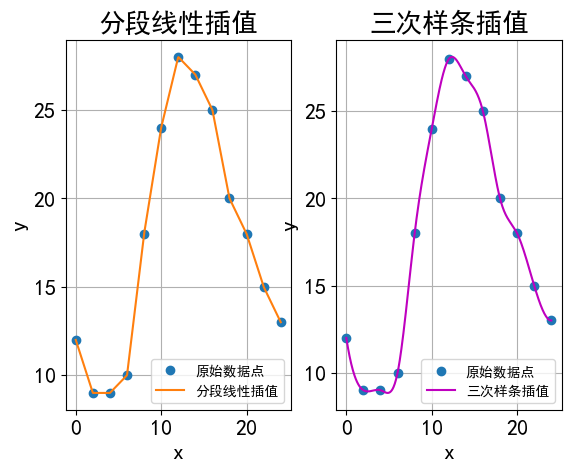

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
x = np.arange(0, 25, 2)
y = np.array([12, 9, 9, 10, 18, 24, 28, 27, 25, 20, 18, 15, 13])
# 构建插值器
ipl = RegularGridInterpolator([x], y)
ipl2 = RegularGridInterpolator([x], y, method='cubic')
x_new = np.linspace(0, 24, 500)  # 插值点
y1_new = ipl(x_new)
y2_new = ipl2(x_new)
plt.rcParams['font.size'] = '16'
plt.rcParams['font.family'] = ['SimHei']
plt.subplot(1, 2, 1)
plt.plot(x, y, 'o', label='原始数据点')
plt.plot(x_new, y1_new, '-', label='分段线性插值')
plt.legend(loc='lower right', fontsize='10')
plt.xlabel('x')
plt.ylabel('y')
plt.title('分段线性插值')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(x, y, 'o', label='原始数据点')
plt.plot(x_new, y2_new, 'm-', label='三次样条插值')
plt.legend(loc='lower right', fontsize='10')
plt.xlabel('x')
plt.ylabel('y')
plt.title('三次样条插值')
plt.grid(True)
plt.savefig("一维插值图.png", dpi=500)
plt.show()

### 2. 二维网格节点插值

思路：将高程数据的x（[0, 1400]）划分为140个小区间，将y（[0, 1200]）划分为120个小区间，于是，将平面划分为140x120个小举行，把对应三维曲面剖分成140x120个小区面进行计算，每个小曲面的面积用对应的三维空间的四个点所构成的两个三角形面积之和作为近似。

计算三角形面积时，使用海伦公式，使用海伦公式，即设 $\Delta ABC$ 的边长分别为 $a,b, c, p = (a+b+c)/2$, 则 $\Delta ABC$ 的面积 $s= \sqrt{p(p－ a)(p－ b)(p－ c)}$．

利用 Python 求得的地表面积的近似值为 $4.7827 \times 10^6 m^2$

#### xx, yy = meshgrid(x, y，indexing='xy/ij', sparce=Ture, copy=Ture)

indexing='xy'：默认第一个维度为y轴，indexing='ij'：第一个维度为x轴  
sparce：是否压缩重复值以减少内存占用  
cope=True：是否返回视图（View）或副本（Copy）

返回值：N 个数组的元组（N = 输入数组个数），每个数组的维度为 (len(x1), len(x2), ..., len(xN))  

区域的面积为：4782742.720125109


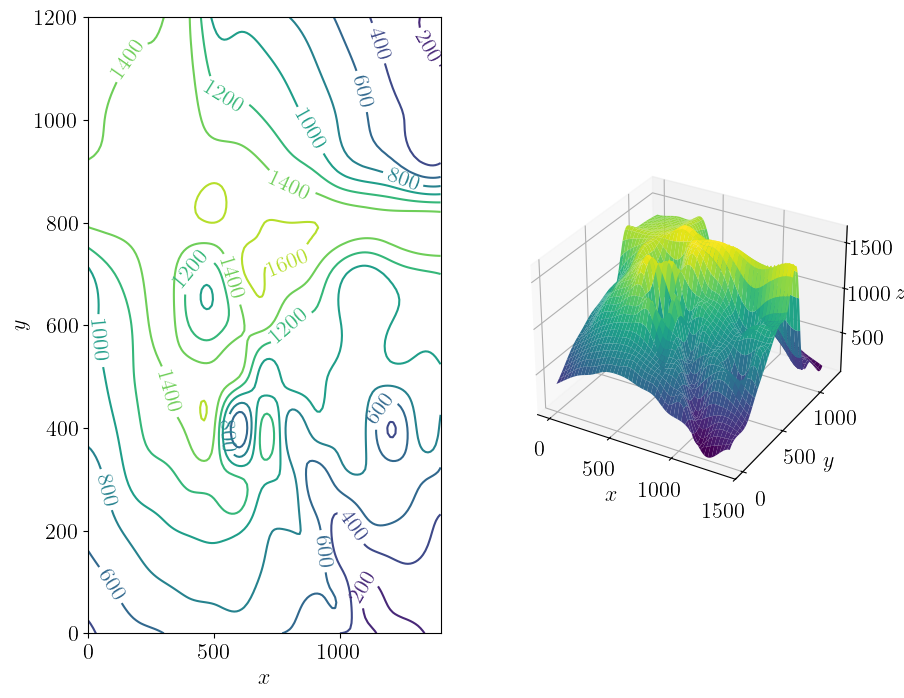

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits import mplot3d

z = np.loadtxt('Pdata7_5.txt')
x = np.arange(0, 1500, 100)  # 15份
y = np.arange(1200, -100, -100)  # 12份
# 注意：z的维度是(12, 15)，需要转置为(15, 12)以匹配x和y的维度

# 海伦公式
def heron(a, b, c):
    p = (a + b + c) / 2
    return np.sqrt(p * (p - a) * (p - b) * (p - c))

# 构建插值器
ipl = RegularGridInterpolator((x, y), z.T, method='cubic')
x_new = np.linspace(0, 1400, 141)
y_new = np.linspace(0, 1200, 121)

'''
xx 是一个 141 × 121 的矩阵，每 列 的值都相同，重复的列数=len(y_new)=121
yy 是一个 141 × 121 的矩阵，每 行 的值都相同, 重复的行数=len(x_new)=141
默认是 indexing='xy'，生成矩阵时第一个维度是 y 轴，第二个维度是 x 轴。
indexing='ij' 强制第一个维度是 x 轴，第二个维度是 y 轴，保证与插值器的输入维度一致
'''
xx, yy = np.meshgrid(x_new, y_new, indexing='ij')  # 生成网格坐标
# z_new 行数对应 x 的维度，列数对应 y 的维度，即 (len(x_new), len(y_new))
z_new = ipl((xx, yy))

m = len(x_new)
n = len(y_new)
s = 0
for i in range(m-1):
    for j in range(n-1):
        # 四个顶点坐标
        # 注意：z_new的维度是(141, 121)，需要使用[i, j]和[i+1, j+1]来索引
        p1 = np.array([x_new[i], y_new[j], z_new[i, j]])
        p2 = np.array([x_new[i], y_new[j+1], z_new[i, j+1]])
        p3 = np.array([x_new[i+1], y_new[j+1], z_new[i+1, j+1]])
        p4 = np.array([x_new[i+1], y_new[j], z_new[i+1, j]])
        # 三角形各边长
        p12 = norm(p1 - p2)
        p23 = norm(p2 - p3)
        p34 = norm(p3 - p4)
        p41 = norm(p4 - p1)
        # 三角形斜边长
        p13 = norm(p1 - p3)
        # 海伦公式求面积
        s += heron(p12, p23, p13) + heron(p34, p41, p13)
        
print(f"区域的面积为：{s}")

# 绘制三维曲面
plt.rcParams['font.size'] = '16'
plt.rcParams['font.family'] = ['SimHei']
plt.rcParams['text.usetex'] = True

fig = plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
contr = plt.contour(x_new, y_new, z_new.T)  # 注意转置z_new的维度，画等高线图
plt.clabel(contr)  # 添加等高线标签
plt.xlabel('$x$')
plt.ylabel('$y$', rotation=90)

ax = plt.subplot(1, 2, 2, projection='3d')
X, Y = np.meshgrid(x_new, y_new)
ax.plot_surface(X, Y, z_new.T, cmap='viridis')  # 注意转置z_new的维度，z的形状(len(y), len(x))
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

plt.savefig("二维插值图.png", dpi=500)
plt.show()

### 3. 二维散乱点插值

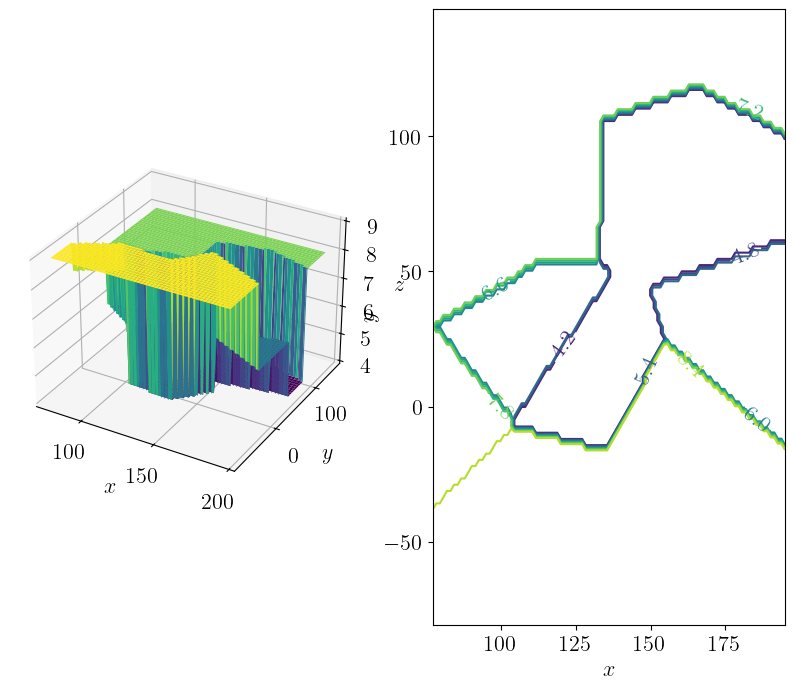

In [28]:
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = np.array([129, 140, 103.5, 88, 185.5, 195, 105, 157.5, 107.5, 77, 81, 162, 162, 117.5])
y = np.array([7.5, 141.5, 23, 147, 22.5, 137.5, 85.5, -6.5, -81, 3, 56.5, -66.5, 84, -33.5])
z = np.array([4, 8, 6, 8, 6, 8, 8, 9, 9, 8, 8, 9, 4, 9])
xy = np.vstack((x, y)).T  # 转置为 (n, 2) 的形状
xn = np.linspace(x.min(), x.max(), 100)  # 插值点
yn = np.linspace(y.min(), y.max(), 100)  # 插值点
X, Y = np.meshgrid(xn, yn)  # 生成网格坐标
Z = griddata(xy, z, (X, Y), method='nearest')  # 使用最近邻插值法

plt.rcParams['font.size'] = '16'
plt.rcParams['text.usetex'] = True

fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(1, 2, 1, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis')  # 绘制三维曲面
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_zlabel('$z$')

plt.subplot(1, 2, 2)
c = plt.contour(X, Y, Z, 8, cmap='viridis')  # 绘制等高线图
plt.clabel(c)  # 添加等高线标签
plt.xlabel('$x$')
plt.ylabel('$y$', rotation=90)
plt.savefig("二维散乱点插值图.png", dpi=500)
plt.show()